In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize

crop_df = pd.read_csv('data/FAOSTAT_Production.csv')
price_df = pd.read_csv('data/FAOSTAT_Producer_Prices.csv')

conn = sqlite3.connect('crop_data.db')

crop_df.to_sql('crop_production', conn, if_exists='replace', index=False)
price_df.to_sql('producer_prices', conn, if_exists='replace', index=False)

214

In [2]:
query = "SELECT * FROM 'crop_production' LIMIT 5"
pd.read_sql_query(query, conn)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,250,France,5312,Area harvested,115,Barley,2014,2014,ha,1764346.0,A,Official value,None
1,QCL,Crops and livestock products,250,France,5412,Yield,115,Barley,2014,2014,kg/ha,6647.5,A,Official value,None
2,QCL,Crops and livestock products,250,France,5510,Production,115,Barley,2014,2014,t,11728556.0,A,Official value,None
3,QCL,Crops and livestock products,250,France,5312,Area harvested,115,Barley,2015,2015,ha,1838689.0,A,Official value,None
4,QCL,Crops and livestock products,250,France,5412,Yield,115,Barley,2015,2015,kg/ha,7123.7,A,Official value,None


In [3]:
query = "SELECT * FROM 'producer_prices' LIMIT 5"
pd.read_sql_query(query, conn)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Months Code,Months,Unit,Value,Flag,Flag Description
0,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2014,2014,7021,Annual value,USD,200.3,A,Official value
1,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2015,2015,7021,Annual value,USD,166.2,A,Official value
2,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2016,2016,7021,Annual value,USD,138.5,A,Official value
3,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2017,2017,7021,Annual value,USD,149.7,A,Official value
4,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2018,2018,7021,Annual value,USD,195.2,A,Official value


The tables have 3 shared keys (Area, Item, Year) that allow them to be joined.

In [4]:
query1 = """
SELECT Item AS 'Crop', Value AS 'Yield', Area AS 'Country'
FROM crop_production
WHERE Year = 2023
AND Element = 'Yield'
AND Area != 'United States of America'
ORDER BY Value DESC
"""

crop_yields = pd.read_sql_query(query1, conn)
crop_yields


,Crop,Yield,Country
0,Maize (corn),9762.5,France
1,Maize (corn),9646.0,Germany
2,Maize (corn),7806.0,Ukraine
3,Wheat,7431.8,Germany
4,Wheat,7201.6,France
5,Barley,6822.9,Germany
6,Barley,6688.8,France
7,Wheat,4642.2,Ukraine
8,Wheat,4152.4,Romania
9,Barley,4013.1,Romania


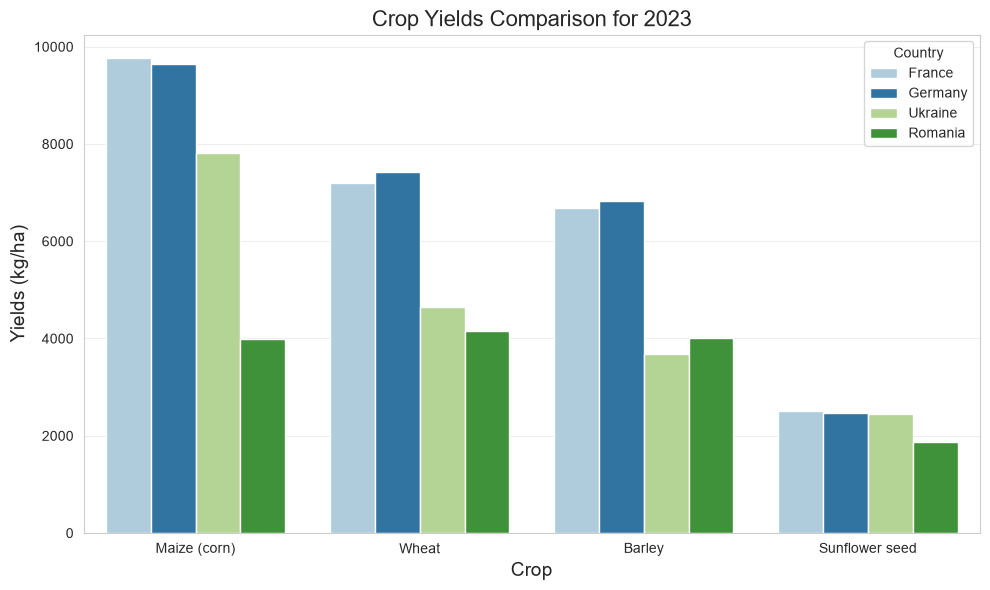

In [5]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=crop_yields, x='Crop', y='Yield', hue='Country', palette='Paired')
plt.title('Crop Yields Comparison for 2023', fontsize=16)
plt.xlabel('Crop', fontsize=14)
plt.ylabel('Yields (kg/ha)', fontsize=14)
plt.tight_layout()
plt.show()

For each crop, is Romania's yield (kg/ha) closer to Ukraine's or to France/Germany's?

For wheat and barley, Romania's yield was closer to Ukraine's. For maize, Romania sat well below even Ukraine's yield, which was closer to that of France of Germany. For Sunflower seeds, Romania fell jsut short of the other countries yields, which were virtually equal.

In [6]:
query = """
SELECT Item AS 'Crop', Area AS 'Country', AVG(Value) AS 'Yield_Average'
FROM crop_production
WHERE Element = 'Yield'
GROUP BY Country, Item
ORDER BY Country, Item;
"""
rel_yield_gap = pd.read_sql_query(query, conn)

rel_yield_gap_pivot = rel_yield_gap.pivot_table(values='Yield_Average', index='Country', columns='Crop')

rel_yield_gap_pivot

Crop,Barley,Maize (corn),Sunflower seed,Wheat
Country,,,,
France,6237.636364,8944.636364,2270.818182,6907.800000
Germany,6745.618182,9507.518182,2185.800000,7571.536364
Romania,3867.945455,4764.345455,2186.972727,4161.618182
Ukraine,3336.054545,6642.936364,2227.281818,4143.409091
United States of America,3943.054545,10985.663636,1859.772727,3215.036364


In [7]:
peers = ['France', 'Germany', 'Ukraine', 'United States of America']
crops = ['Barley', 'Maize (corn)', 'Sunflower seed', 'Wheat']

result_df = pd.DataFrame(index=peers, columns=crops)

for peer in peers:
    for crop in crops:
        peer_yield = rel_yield_gap_pivot.loc[peer, crop]
        ro_yield = rel_yield_gap_pivot.loc['Romania', crop]
        gap = ((peer_yield - ro_yield) / peer_yield) * 100
        result_df.loc[peer, crop] = round(gap, 2)

result_df = result_df.rename(index={'United States of America': 'USA'}).astype(float)
result_df

,Barley,Maize (corn),Sunflower seed,Wheat
France,37.99,46.74,3.69,39.75
Germany,42.66,49.89,-0.05,45.04
Ukraine,-15.94,28.28,1.81,-0.44
USA,1.90,56.63,-17.59,-29.44


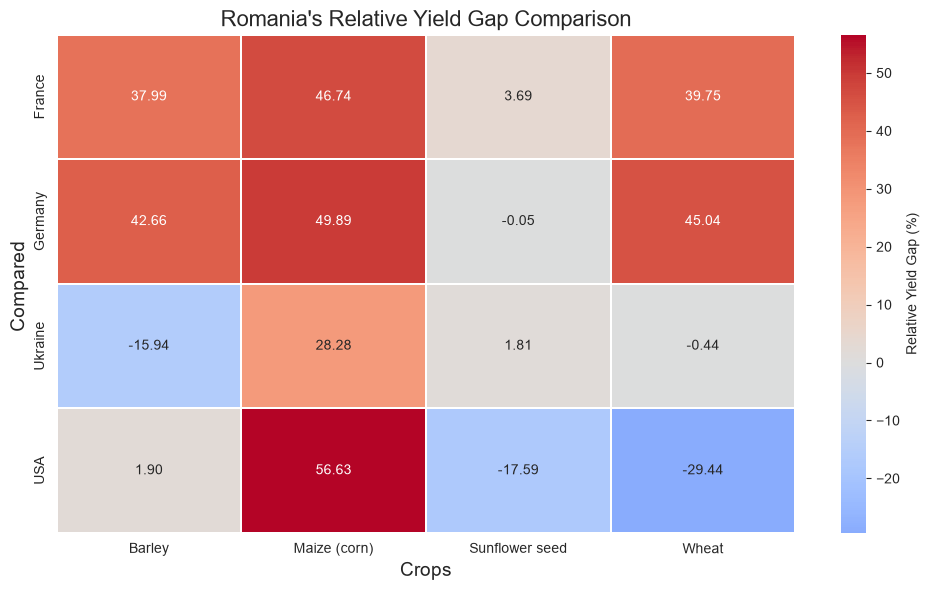

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(data=result_df.astype(float),
            cmap='coolwarm',
            annot=True, fmt='.2f',
            center=0,
            linewidths=0.1, linecolor='white',
            cbar_kws={'label': 'Relative Yield Gap (%)'}
)
plt.title("Romania's Relative Yield Gap Comparison", fontsize=16)
plt.xlabel('Crops', fontsize=14)
plt.ylabel('Compared ', fontsize=14)
plt.tight_layout()
plt.show()

What is Romania's relative yield gap, in percentage terms, to each of the four peer countries, per crop?

Gap = `(peer_yield − Romania_yield) / peer_yield × 100`. Positive = Romania trails, Negative = Romania leads.

- **Barley**: Romania has close to 40% worse yield than France and Germany, 16% better yield than Ukraine and almost the same yield as the USA.
- **Maize**: Romania is significantly behind all peers, at around 50%, except Ukraine which still has almost 30% more.
- **Sunflower**: Most competitive crop for Romania, having about the same yields as all peers except the USA, which is outperformed at around 18% more yield.
- **Wheat**: Romania has a similar relative yield gaps with France and Germany at around 40-45%, matches Ukraine's yield and outperforms the USA again with almost 30% better yields.

**Pattern**:Romania consistently lags France and Germany across all crops, except for Sunflower (where it is competitive). Ukraine’s performance flips by crop: it is better in Maize, worse in Barley, and about the same in sunflower seeds and wheat. USA is the most extreme comparison: Romania has the largest deficit in Maize and largest lead in Sunflower and Wheat.

**Note**: Ukraine’s figures may reflect disruptions from the the war, including land loss and reduced harvested area post 2021.

In [9]:
query = """
SELECT Area AS 'Country', Item AS 'Crop', Value AS 'Yield', Year
FROM crop_production
WHERE Country IN ('Romania', 'Germany')
AND Element = 'Yield'
GROUP BY Country, Item, Year
ORDER BY Country, Item, Year
"""
ro_ger_comp = pd.read_sql_query(query, conn)

ro_ger_comp_pivot = ro_ger_comp.pivot_table(index=('Country', 'Crop'), columns='Year', values='Yield')

romania = ro_ger_comp_pivot.loc['Romania']
germany = ro_ger_comp_pivot.loc['Germany']

ro_ger_comp_pivot

Year                       2014    2015    2016     2017    2018    2019  \
Country Crop                                                               
Germany Barley           7347.5  7171.0  6685.7   6930.2  5766.3  6783.4   
        Maize (corn)    10683.8  8722.3  9651.2  10526.9  8139.0  8809.6   
        Sunflower seed   2300.0  1918.5  2137.7   2200.0  1820.5  2044.4   
        Wheat            8629.6  8087.7  7640.9   7644.3  6673.7  7396.4   
Romania Barley           3343.8  3470.8  3778.6   4190.3  4417.3  4188.0   
        Maize (corn)     4787.0  3471.6  4167.7   5961.0  7636.8  6499.9   
        Sunflower seed   2193.6  1769.6  1957.2   2915.2  3041.4  2782.5   
        Wheat            3598.4  3787.2  3948.4   4891.1  4793.5  4748.8   

Year                      2020     2021    2022    2023     2024  
Country Crop                                                      
Germany Barley          6459.1   6762.7  7081.4  6822.9   6391.6  
        Maize (corn)    9587.4  10360.8  8402.5  9646.0  10053.2  
        Sunflower seed  2056.7   2603.1  1883.2  2468.8   2610.9  
        Wheat           7819.5   7301.5  7577.3  7431.8   7084.2  
Romania Barley          2581.6   4408.3  4006.7  4013.1   4148.9  
        Maize (corn)    3974.2   5801.4  3297.7  3981.6   2828.9  
        Sunflower seed  1857.5   2529.9  1926.9  1870.0   1212.9  
        Wheat           2966.0   4796.9  4004.4  4152.4   4090.7

In [10]:
romania_pct_of_germany = ((romania / germany) * 100).round(1)
romania_pct_of_germany

Year,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Crop,,,,,,,,,,,
Barley,45.5,48.4,56.5,60.5,76.6,61.7,40.0,65.2,56.6,58.8,64.9
Maize (corn),44.8,39.8,43.2,56.6,93.8,73.8,41.5,56.0,39.2,41.3,28.1
Sunflower seed,95.4,92.2,91.6,132.5,167.1,136.1,90.3,97.2,102.3,75.7,46.5
Wheat,41.7,46.8,51.7,64.0,71.8,64.2,37.9,65.7,52.8,55.9,57.7


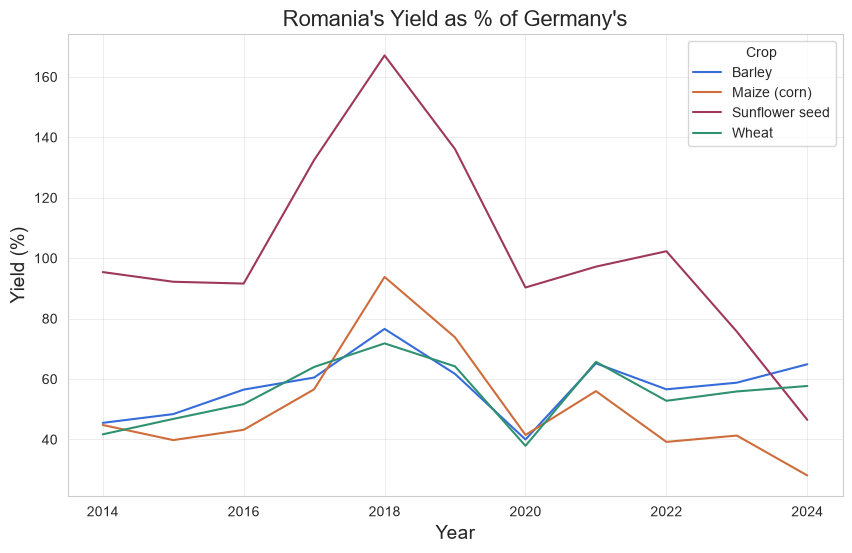

In [11]:
romania_pct_of_germany.T.plot(figsize=(10, 6))
plt.title("Romania's Yield as % of Germany's", fontsize=16)
plt.ylabel('Yield (%)', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.show()

Tracking Romania's yield as a percentage of Germany's yield, year by year.

Romania trailed Germany in yield for every crop across the whole decade, with sunflower seed as the one exception. Sunflower seed exceeded Germany's yield twice: a sustained peak in 2017–2019 (167% in 2018) and a brief return above parity in 2022 (\~102%), before falling well below parity by 2024 (47%). The year 2020 also stands out as a shared low point across all four crops. Maize and sunflower seed specifically have had a dramatic gap widening from 2018 to 2024 with a downward trend. Barley and wheat followed very similar trends for the whole period, with a gradual upward trend from 2014 (~40-45%) to 2024 (\~58-65%), with a shared sharp dip in 2020.

To confirm these relative shifts weren't just an artifact of comparing to Germany, absolute yield values were checked directly for the two standout years:

- **2020:** Romania's own yields fell sharply across all four crops (roughly
  33–39% year-over-year), while Germany's yields were flat or slightly up.
  The 2020 dip reflects a real collapse in Romania's production, consistent
  with the severe drought reported across south-eastern Europe that year.

- **2018:** Romania's yields held steady or grew (maize +28%), while Germany's
  fell 13–23% across all crops amid its own drought conditions that year.
  The 167% sunflower peak reflects genuine gains in Romania and genuine
  losses in Germany happening simultaneously.

In [12]:
query = """
WITH production AS (
    SELECT Area, Item, Year, Value AS Production
    FROM crop_production
    WHERE Element = 'Production'
),
area_harvested AS (
    SELECT Area, Item, Year, Value AS AreaHarvested
    FROM crop_production
    WHERE Element = 'Area harvested'
)
SELECT
    p.Area AS Country,
    p.Item AS Crop,
    p.year,
    p.Production,
    a.AreaHarvested,
    pr.Value AS Price
FROM production p
JOIN area_harvested a
ON p.Area = a.Area AND p.Item = a.Item AND p.Year = a.Year
JOIN producer_prices pr
ON p.Area = pr.Area AND p.Item = pr.Item AND p.Year = pr.Year
"""
df = pd.read_sql_query(query, conn)
df

,Country,Crop,Year,Production,AreaHarvested,Price
0,France,Barley,2014,11728556.0,1764346.0,200.3
1,France,Barley,2015,13098233.9,1838689.0,166.2
2,France,Barley,2016,10439229.0,1917549.0,138.5
3,France,Barley,2017,12086796.0,1904872.0,149.7
4,France,Barley,2018,11042820.0,1767970.0,195.2
...,...,...,...,...,...,...
209,United States of America,Wheat,2020,49751180.0,14888140.0,184.0
210,United States of America,Wheat,2021,44803690.0,15032210.0,268.2
211,United States of America,Wheat,2022,44897830.0,14360420.0,330.7
212,United States of America,Wheat,2023,49313930.0,15083610.0,255.7


In [13]:
value_df = df[['Country', 'Crop', 'Year']].copy()
value_df['ValuePerHa'] = (df['Price'] * df['Production']) / df['AreaHarvested']

value_pivot = value_df.pivot_table(values='ValuePerHa', index='Country', columns='Crop')
value_pivot.round(1)

Crop,Barley,Maize (corn),Sunflower seed,Wheat
Country,,,,
France,1296.9,1869.0,1190.6,1505.0
Germany,1299.3,2019.6,878.6,1618.7
Romania,863.9,967.6,859.0,844.4
Ukraine,510.3,1081.2,848.0,673.5
United States of America,995.6,1839.4,861.8,671.9


In [14]:
value_rank = value_pivot.rank(ascending=False)
value_rank

Crop,Barley,Maize (corn),Sunflower seed,Wheat
Country,,,,
France,2.0,2.0,1.0,2.0
Germany,1.0,1.0,2.0,1.0
Romania,4.0,5.0,4.0,3.0
Ukraine,5.0,4.0,5.0,4.0
United States of America,3.0,3.0,3.0,5.0


In [15]:
yield_rank = rel_yield_gap_pivot.rank(ascending=False)
yield_rank

Crop,Barley,Maize (corn),Sunflower seed,Wheat
Country,,,,
France,2.0,3.0,1.0,2.0
Germany,1.0,2.0,4.0,1.0
Romania,4.0,5.0,3.0,3.0
Ukraine,5.0,4.0,2.0,4.0
United States of America,3.0,1.0,5.0,5.0


In [16]:
romania_compare = pd.DataFrame({
    'Yield Rank': yield_rank.loc['Romania'],
    'Value/ha Rank': value_rank.loc['Romania']
})
romania_compare['Change'] = romania_compare['Yield Rank'] - romania_compare['Value/ha Rank']

romania_compare

,Yield Rank,Value/ha Rank,Change
Crop,,,
Barley,4.0,4.0,0.0
Maize (corn),5.0,5.0,0.0
Sunflower seed,3.0,4.0,-1.0
Wheat,3.0,3.0,0.0


Romania's rank among its 4 peers by production value per hectare, vs. its yield-only rank:

Values are averaged across 2014–2024, covering Romania vs. France, Germany, Ukraine, and the USA, for barley, maize, sunflower seed, and wheat. Calculated by joining `crop_production` and `producer_prices` on Area/Item/Year.

Romania's ranking is stable across 3 of 4 crops. It's standing on land productivity mirrors its standing on raw yield. The one exception, sunflower seed, is a marginal case: Romania (859.0 USD/ha) trails the USA (861.8 USD/ha) by under 1%, so the rank drop reflects a near-tie rather than a meaningful productivity gap. Romania remains last among its peers on maize and consistently mid-pack on barley and wheat, regardless of whether output is measured in kg/ha or USD/ha.

**Note:** Ukraine's producer prices are missing for 2024 across all four crops (likely wartime disruption). Ukraine's 2014–2024 average is built on 10 of the 11 years, not the full window like the other four countries.

In [17]:
shock_query = """
SELECT Area AS Country, Item AS Crop, Year, Element, Value
FROM crop_production
WHERE Area IN ('Romania', 'Ukraine')
AND Element IN ('Production', 'Area harvested')
AND Year BETWEEN 2020 AND 2024
ORDER BY Country, Crop, Element, Year
"""
shock_df = pd.read_sql_query(shock_query, conn)
shock_pivot = shock_df.pivot_table(index=['Country','Crop','Element'], columns='Year', values='Value')
shock_pct = (shock_pivot.pct_change(axis=1) * 100).round(1)
shock_2022 = shock_pct[2022].unstack('Element')
shock_2022

Element                 Area harvested  Production
Country Crop                                      
Romania Barley                    -5.2       -13.9
        Maize (corn)              -4.6       -45.8
        Sunflower seed            -2.7       -25.9
        Wheat                     -0.3       -16.8
Ukraine Barley                   -29.6       -40.6
        Maize (corn)             -24.8       -37.8
        Sunflower seed           -21.4       -30.9
        Wheat                    -25.6       -35.6

<Figure size 1000x600 with 0 Axes>

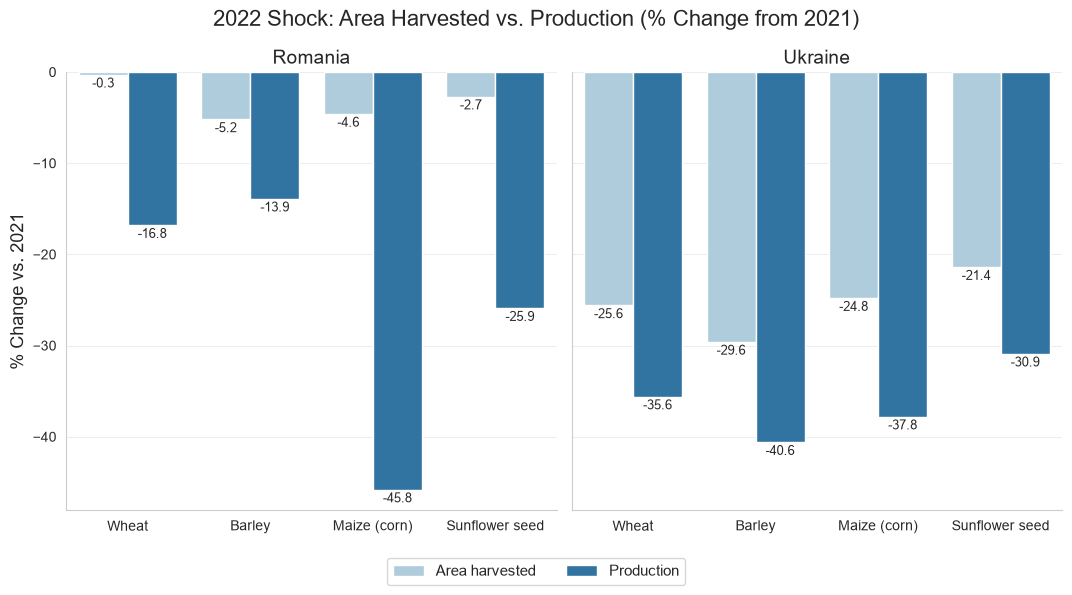

In [18]:
shock_long = shock_2022.reset_index().melt(id_vars=['Country', 'Crop'], var_name='Element', value_name='% Change')
crop_order = ['Wheat', 'Barley', 'Maize (corn)', 'Sunflower seed']
plt.figure(figsize=(10, 6))
g = sns.catplot(
    data=shock_long, kind='bar',
    x='Crop', y='% Change', hue='Element',
    col='Country', order=crop_order,
    palette='Paired',
    height=5.5, aspect=0.85, sharey=True
)

g.figure.suptitle('2022 Shock: Area Harvested vs. Production (% Change from 2021)', fontsize=16)
g.set_axis_labels('', '% Change vs. 2021', fontsize=13)
g.set_titles('{col_name}', size=14)
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', fontsize=9, padding=2)
sns.move_legend(g, 'lower center', bbox_to_anchor=(0.5, -0.08), ncol=2, title=None, frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

Romania was not directly affected by the Russian invasion of Ukraine, though it's production fell sharply in 2022. The reason for this, as external reporting suggests, was that 2022 was independently a severe drought year in Romania, affecting all crop yields. We need to consider the fact that Ukraine's crop production fell sharply alongside it's harvested area, showing clear correlation to the war.

In [19]:
query = """
SELECT Item AS Crop, Year, Value AS Yield
FROM crop_production
WHERE Area = 'Romania'
AND Element = 'Yield'
ORDER BY Item, Year
"""
ro_yield = pd.read_sql_query(query, conn)
ro_yield_pivot = ro_yield.pivot_table(index='Crop', columns='Year', values='Yield')

decade_avg = ro_yield_pivot.loc[:, 2014:2023].mean(axis=1)
pct_vs_avg = ((ro_yield_pivot[2024] - decade_avg) / decade_avg * 100).round(1)

decade_summary = pd.DataFrame({
    '2014-2023 Avg': decade_avg.round(0),
    '2024': ro_yield_pivot[2024],
    '% vs Decade Avg': pct_vs_avg
})
decade_summary

,2014-2023 Avg,2024,% vs Decade Avg
Crop,,,
Barley,3840.0,4148.9,8.0
Maize (corn),4958.0,2828.9,-42.9
Sunflower seed,2284.0,1212.9,-46.9
Wheat,4169.0,4090.7,-1.9


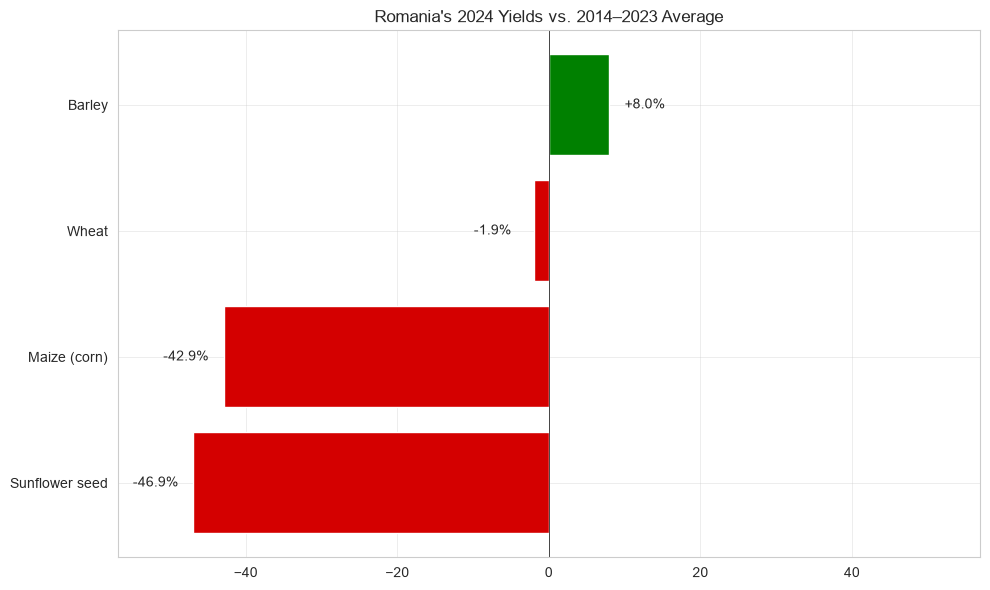

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

decade_sort = decade_summary.sort_values('% vs Decade Avg')
pda = decade_sort['% vs Decade Avg']
bars = ax.barh(range(len(decade_sort)), pda,
               color=['#d40000' if v < 0 else 'green' for v in pda])

for i, (bar, pct) in enumerate(zip(bars, pda)):
    ax.text(bar.get_width() + (1 if pct >= 0 else -4) * 2,
            bar.get_y() + bar.get_height()/2,
            f'{pct:+.1f}%',
            va='center', fontsize=10)

ax.set_yticks(range(len(decade_sort)))
ax.set_yticklabels(decade_sort.index)

ax.set_title("Romania's 2024 Yields vs. 2014–2023 Average")

ax.axvline(0, color='black', linewidth=0.5)

pad = 10
limit = max(abs(pda.min()), abs(pda.max())) + pad
ax.set_xlim(-limit, limit)

plt.tight_layout()
plt.show()


Looking at the 2024 harvest compared to the rest of the decade: maize and sunflower are each the single lowest year of the entire 2014–2024 window; barley and wheat are at normal levels.

Reporting confirms severe drought hit Romania again in 2024, affecting summer crops in particular.